# TriDep — 02 — Train & Evaluate

Two **completely separate** evaluation pipelines run in this notebook:

| | **Baseline (Initial Approach)** | **Improved (Refined Approach)** |
|---|---|---|
| Method | LOSOCV (Leave-One-Subject-Out CV) | 5-Fold Stratified CV |
| Model | Simple fusion — Dense only, no BatchNorm | Improved fusion — BatchNorm + L2 reg |
| Loss function | Binary Cross-Entropy | Focal Loss (γ=2, α=0.25) |
| Class balancing | **None** | SMOTE on training folds only |
| Decision threshold | Fixed **0.5** | Optimal Youden J |
| Text model | SBERT only | SBERT + pretrained InducT-GCN |
| Output folder | **`Baseline_Results/Baseline_*`** | **`Improved_Results/Improved_*`** |

**Run order:**
1. Cell 1 — Mount + restore cache
2. Cell 2 — Feature assembly + both model definitions
3. Cell 3 — Demo prep (Improved model)
4. **Cell 4 — Baseline LOSOCV** → `Baseline_Results/Baseline_losocv_predictions.csv`
5. **Cell 5 — Improved 5-Fold CV** → `Improved_Results/Improved_all_predictions.csv`
6. Cell 6 — Full comparison table (Baseline + all Improved models)
7. Cell 7 — Baseline plots → `Baseline_Results/Baseline_figs/`
8. Cell 8 — Improved plots → `Improved_Results/Improved_figs/`
9. Cell 9 — Stage 6 summary visualizations
10. Cell 10 — Class distribution

**Prerequisite:** `01_preprocess.ipynb` must have been run first.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

BASELINE_DIR    = Path('/content/drive/MyDrive/Baseline_Results')
IMPROVED_DIR    = Path('/content/drive/MyDrive/Improved_Results')
CACHE_DIR = Path('/content/cache')
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
IMPROVED_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

# Restore from whichever backup exists (prefer Improved, fall back to Baseline)
IMPROVED_ZIP = IMPROVED_DIR / 'Improved_cache_backup.zip'
BASELINE_ZIP = BASELINE_DIR / 'Baseline_cache_backup.zip'

if IMPROVED_ZIP.exists():
    shutil.unpack_archive(str(IMPROVED_ZIP), '/content/cache', 'zip')
    print('Cache restored from Improved_Results/Improved_cache_backup.zip')
elif BASELINE_ZIP.exists():
    shutil.unpack_archive(str(BASELINE_ZIP), '/content/cache', 'zip')
    print('Cache restored from Baseline_Results/Baseline_cache_backup.zip')
else:
    print('ERROR: No backup found. Run 01_preprocess.ipynb first.')
    print('  Expected:', IMPROVED_ZIP, 'or', BASELINE_ZIP)

Mounted at /content/drive
Cache restored from AR_Results/AR_cache_backup.zip


In [ ]:
# ============================================================
# STAGE 4 — FEATURE ASSEMBLY + BOTH MODEL DEFINITIONS
# ============================================================
import numpy as np
import pandas as pd
import random, os
import tensorflow as tf
from pathlib import Path
from tensorflow.keras import layers, models, regularizers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

CACHE_DIR = Path('/content/cache')
BASELINE_DIR    = Path('/content/drive/MyDrive/Baseline_Results')
IMPROVED_DIR    = Path('/content/drive/MyDrive/Improved_Results')
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
IMPROVED_DIR.mkdir(parents=True, exist_ok=True)

labels = pd.read_csv(CACHE_DIR / 'labels.csv')

def load_subject(pid):
    d = CACHE_DIR / str(pid)
    audio_vec = np.load(d / 'wav2vec.npy')
    fau       = np.load(d / 'fau.npy')
    text      = np.load(d / 'text_emb.npy')
    fau_vec   = fau.mean(axis=0) if fau.shape[0] > 0 else np.zeros(20, dtype=np.float32)
    gcn_path  = d / 'inductgcn_prob.npy'
    gcn_prob  = float(np.load(gcn_path)[0]) if gcn_path.exists() else -1.0
    return audio_vec.astype(np.float32), fau_vec.astype(np.float32), \
           text.astype(np.float32), gcn_prob

A, F, T, GCN_PROBS, Y, PIDS = [], [], [], [], [], []
for _, row in labels.iterrows():
    pid = int(row['participant_id'])
    try:
        a, f, t, gcn_p = load_subject(pid)
        A.append(a); F.append(f); T.append(t); GCN_PROBS.append(gcn_p)
        Y.append(int(row['label'])); PIDS.append(pid)
    except FileNotFoundError:
        print(f'  [skip {pid}] missing cached features')

A         = np.array(A,         dtype=np.float32)
F         = np.array(F,         dtype=np.float32)
T         = np.array(T,         dtype=np.float32)
GCN_PROBS = np.array(GCN_PROBS, dtype=np.float32)
Y         = np.array(Y,         dtype=np.int32)
PIDS      = np.array(PIDS)

HAS_GCN = (GCN_PROBS >= 0).all()

print('Audio       :', A.shape)
print('FAU         :', F.shape)
print('Text (SBERT):', T.shape)
print('InducT-GCN  :', GCN_PROBS.shape, f'(loaded: {HAS_GCN})')
print('Labels      :', Y.shape, ' positives:', Y.sum())

AUDIO_DIM = A.shape[1]
FAU_DIM   = F.shape[1]
TEXT_DIM  = T.shape[1]

# ╔═══════════════════════════════════════════════════════════╗
# ║  BASELINE MODEL — initial simple fusion design                        ║
# ║  Dense only, no BatchNorm, no L2 regularisation           ║
# ╚═══════════════════════════════════════════════════════════╝
def build_model_baseline(audio_dim=AUDIO_DIM, fau_dim=FAU_DIM, text_dim=TEXT_DIM):
    audio_in = layers.Input(shape=(audio_dim,), name='audio_in')
    a = layers.Dense(128, activation='relu')(audio_in)
    a = layers.Dropout(0.3)(a)
    audio_repr = layers.Dense(64, activation='relu')(a)

    fau_in = layers.Input(shape=(fau_dim,), name='fau_in')
    v = layers.Dense(64, activation='relu')(fau_in)
    v = layers.Dropout(0.3)(v)
    video_repr = layers.Dense(32, activation='relu')(v)

    text_in = layers.Input(shape=(text_dim,), name='text_in')
    t = layers.Dense(256, activation='relu')(text_in)
    t = layers.Dropout(0.3)(t)
    t = layers.Dense(128, activation='relu')(t)
    text_repr = layers.Dense(64, activation='relu')(t)

    fused = layers.Concatenate()([audio_repr, video_repr, text_repr])
    x = layers.Dense(128, activation='relu')(fused)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    return models.Model(inputs=[audio_in, fau_in, text_in], outputs=out)

# ╔═══════════════════════════════════════════════════════════╗
# ║  Improved MODEL — improved                                      ║
# ║  BatchNorm + Dropout + L2 regularisation                  ║
# ╚═══════════════════════════════════════════════════════════╝
def build_model_improved(audio_dim=AUDIO_DIM, fau_dim=FAU_DIM, text_dim=TEXT_DIM):
    audio_in = layers.Input(shape=(audio_dim,), name='audio_in')
    a = layers.Dense(256, activation='relu')(audio_in)
    a = layers.BatchNormalization()(a)
    a = layers.Dropout(0.5)(a)
    a = layers.Dense(128, activation='relu')(a)
    a = layers.BatchNormalization()(a)
    a = layers.Dropout(0.4)(a)
    audio_repr = layers.Dense(64, activation='relu')(a)

    fau_in = layers.Input(shape=(fau_dim,), name='fau_in')
    v = layers.Dense(64, activation='relu')(fau_in)
    v = layers.BatchNormalization()(v)
    v = layers.Dropout(0.3)(v)
    video_repr = layers.Dense(32, activation='relu')(v)

    text_in = layers.Input(shape=(text_dim,), name='text_in')
    t = layers.Dense(256, activation='relu')(text_in)
    t = layers.BatchNormalization()(t)
    t = layers.Dropout(0.4)(t)
    t = layers.Dense(128, activation='relu')(t)
    t = layers.BatchNormalization()(t)
    t = layers.Dropout(0.3)(t)
    text_repr = layers.Dense(64, activation='relu')(t)

    fused = layers.Concatenate()([audio_repr, video_repr, text_repr])
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    return models.Model(inputs=[audio_in, fau_in, text_in], outputs=out)

# alias used by demo prep cell
build_model = build_model_improved

print('Baseline model params:', build_model_baseline().count_params())
print('Improved model params:', build_model_improved().count_params())
print('Both model definitions ready.')

Audio       : (189, 1536)
FAU         : (189, 20)
Text (SBERT): (189, 768)
InducT-GCN  : (189,) (loaded: True)
Labels      : (189,)  positives: 56
TN model params: 477409
AR model params: 710881
Both model definitions ready.


In [ ]:
# ============================================================
# DEMO PREP — Trains final Improved model on ALL subjects
# Saves everything your UI demo needs to Drive directly.
#
# After running this cell, download from Drive:
#   Improved_Results/Improved_fusion_model.keras   ← load this in your UI
#   Improved_Results/Improved_demo_data.npz        ← pre-computed features for all subjects
#   Improved_Results/Improved_demo_samples/        ← 10 sample subjects for panel demo
# ============================================================
import numpy as np, tensorflow as tf, os, shutil
from tensorflow.keras import backend as K
from imblearn.over_sampling import SMOTE
from pathlib import Path

os.makedirs("/content/demo", exist_ok=True)
IMPROVED_DIR = Path('/content/drive/MyDrive/Improved_Results')
IMPROVED_DIR.mkdir(parents=True, exist_ok=True)

# ── Focal loss ────────────────────────────────────────────────────────────
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce  = -(y_true*tf.math.log(y_pred) + (1-y_true)*tf.math.log(1-y_pred))
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        a_t = y_true*alpha  + (1-y_true)*(1-alpha)
        return tf.reduce_mean(a_t * tf.pow(1-p_t, gamma) * ce)
    return loss_fn

# ── Train final model on ALL subjects with SMOTE ──────────────────────────
print('Training final Improved model on all subjects...')
Xall  = np.concatenate([A, F, T], axis=1)
a_dim = A.shape[1]; f_dim = F.shape[1]; t_dim = T.shape[1]

n_min = int(min(np.sum(Y==0), np.sum(Y==1)))
sm    = SMOTE(random_state=42, k_neighbors=max(1, min(5, n_min-1)))
Xbal, Ybal = sm.fit_resample(Xall, Y)
Abal = Xbal[:, :a_dim]
Fbal = Xbal[:, a_dim:a_dim+f_dim]
Tbal = Xbal[:, a_dim+f_dim:]

K.clear_session()
final_model = build_model()
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(), metrics=['accuracy'])
final_model.fit(
    [Abal, Fbal, Tbal], Ybal,
    epochs=60, batch_size=16, verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='loss', patience=8, restore_best_weights=True)])

# ── Save model directly to Drive ──────────────────────────────────────────
MODEL_PATH = str(IMPROVED_DIR / 'Improved_fusion_model.keras')
final_model.save(MODEL_PATH)
print(f'Model saved to Drive: {MODEL_PATH}')
print(f'  Input 1 (audio) : shape (1, {a_dim})')
print(f'  Input 2 (video) : shape (1, {f_dim})')
print(f'  Input 3 (text)  : shape (1, {t_dim})')
print(f'  Output          : shape (1, 1)  — P(depressed)')

# ── Save all subject features to Drive ───────────────────────────────────
DATA_PATH = str(IMPROVED_DIR / 'Improved_demo_data.npz')
np.savez(DATA_PATH, A=A, F=F, T=T, Y=Y, PIDS=np.array(PIDS))
print(f'Demo data saved: {DATA_PATH}')

# ── Save 10 sample subjects (5 depressed + 5 healthy) for panel demo ─────
SAMPLES_DIR = IMPROVED_DIR / 'Improved_demo_samples'
SAMPLES_DIR.mkdir(exist_ok=True)

dep_idx     = np.where(Y == 1)[0][:5]
healthy_idx = np.where(Y == 0)[0][:5]
sample_idxs = list(dep_idx) + list(healthy_idx)

import pandas as pd
sample_records = []
for idx in sample_idxs:
    pid  = int(PIDS[idx])
    prob = float(final_model.predict(
        [A[idx:idx+1], F[idx:idx+1], T[idx:idx+1]], verbose=0).ravel()[0])
    pred = int(prob >= 0.5)
    true = int(Y[idx])
    np.savez(str(SAMPLES_DIR / f'subject_{pid}.npz'),
             audio=A[idx], video=F[idx], text=T[idx],
             true_label=true, pred_prob=prob)
    sample_records.append({
        'participant_id': pid,
        'true_label':     true,
        'true_class':     'Depressed' if true == 1 else 'Healthy',
        'pred_prob':      round(prob, 4),
        'pred_label':     pred,
        'pred_class':     'Depressed' if pred == 1 else 'Healthy',
        'correct':        true == pred,
    })
    print(f'  Subject {pid}: true={true} | P(dep)={prob:.3f} | pred={pred} | {"✓" if true==pred else "✗"}')

pd.DataFrame(sample_records).to_csv(
    str(IMPROVED_DIR / 'AR_demo_sample_predictions.csv'), index=False)

print(f'\nAll demo files saved to Drive:')
print(f'  Improved_fusion_model.keras          ← load in UI')
print(f'  Improved_demo_data.npz               ← all {len(Y)} subjects features')
print(f'  Improved_demo_samples/               ← 10 pre-selected subjects')
print(f'  AR_demo_sample_predictions.csv ← predictions table for panel')

Training final AR model on all subjects...
Epoch 1/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5038 - loss: 0.3649
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5188 - loss: 0.1740
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5602 - loss: 0.1408
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5489 - loss: 0.1359
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5526 - loss: 0.1286
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6391 - loss: 0.1236
Epoch 7/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6015 - loss: 0.1071
Epoch 8/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6203 - loss: 0.1050
Epoch 9/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6805 - loss: 0.0903
Epoch 10/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6729 - loss: 0.0934
Epoch 11/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6541 - loss: 0.0980
Epoch 12/60
17/17 ━━

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Baseline                                                                   ║
# ║  LOSOCV | Simple Fusion Model | BCE Loss | No SMOTE | Threshold=0.5   ║
# ║  Saves to: Baseline_Results/Baseline_*                                            ║
# ╚═══════════════════════════════════════════════════════════════════════╝
# NOTE: LOSOCV trains one model per subject (~189 models) and takes
#       3-4 hours on GPU. If Baseline_losocv_predictions.csv already exists
#       on Drive it is loaded instantly, skipping training entirely.
# ============================================================

import time, numpy as np, tensorflow as tf, pandas as pd
from tensorflow.keras import backend as K
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)

tf.get_logger().setLevel('ERROR')
gpus = tf.config.list_physical_devices('GPU')
DEVICE = '/GPU:0' if gpus else '/CPU:0'
print('Baseline — LOSOCV | GPU available:', bool(gpus))

BASELINE_PRED_FILE = BASELINE_DIR / 'Baseline_losocv_predictions.csv'

# ── Try to load cached predictions first ─────────────────────────────────
if BASELINE_PRED_FILE.exists():
    print(f'Loading existing Baseline predictions from Drive...')
    baseline_df     = pd.read_csv(BASELINE_PRED_FILE)
    baseline_y_true = baseline_df['y_true'].values.astype(int)
    baseline_y_prob = baseline_df['y_prob'].values
    baseline_y_pred = baseline_df['y_pred'].values.astype(int)
    baseline_pids   = baseline_df['participant_id'].values
    print(f'  Loaded {len(baseline_df)} Baseline subjects (skipped training).')

else:
    # ── Run full LOSOCV ───────────────────────────────────────────────────
    print(f'Running LOSOCV on {len(Y)} subjects — ESTIMATED 3-4 HOURS...')
    Xall  = np.concatenate([A, F, T], axis=1)
    a_dim = A.shape[1]; f_dim = F.shape[1]; t_dim = T.shape[1]

    baseline_y_true = np.zeros(len(Y), dtype=int)
    baseline_y_prob = np.zeros(len(Y))
    t_start   = time.time()

    for i in range(len(Y)):
        tr_idx  = [j for j in range(len(Y)) if j != i]
        val_idx = [i]

        Atr = A[tr_idx]; Ftr = F[tr_idx]; Ttr = T[tr_idx]; Ytr = Y[tr_idx]
        Av  = A[val_idx]; Fv  = F[val_idx]; Tv  = T[val_idx]

        K.clear_session()
        tf.random.set_seed(SEED)
        with tf.device(DEVICE):
            m = build_model_baseline()
            m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss='binary_crossentropy', metrics=['accuracy'])
            es = tf.keras.callbacks.EarlyStopping(
                monitor='loss', patience=10, restore_best_weights=True)
            m.fit([Atr, Ftr, Ttr], Ytr,
                  epochs=50, batch_size=16,
                  verbose=0, callbacks=[es])

        baseline_y_prob[i] = float(m.predict([Av, Fv, Tv], verbose=0).ravel()[0])
        baseline_y_true[i] = int(Y[i])

        if (i + 1) % 20 == 0:
            elapsed = (time.time() - t_start) / 60
            eta     = elapsed / (i + 1) * (len(Y) - i - 1)
            print(f'  {i+1}/{len(Y)} done | {elapsed:.1f} min | ~{eta:.1f} min left')

    baseline_y_pred = (baseline_y_prob >= 0.5).astype(int)
    baseline_pids   = PIDS

    # save predictions to Baseline_Results
    pd.DataFrame({
        'participant_id': baseline_pids,
        'y_true':         baseline_y_true,
        'y_prob':         baseline_y_prob,
        'y_pred':         baseline_y_pred,
    }).to_csv(BASELINE_PRED_FILE, index=False)
    print(f'Baseline LOSOCV predictions saved → {BASELINE_PRED_FILE}')

# ── Baseline metrics (threshold = 0.5) ─────────────────────────────────────────
print('\n====== Baseline — LOSOCV Results (Initial Approach) ======')
print(f'  Subjects        : {len(baseline_y_true)} '
      f'(dep={int(baseline_y_true.sum())} / healthy={int((baseline_y_true==0).sum())})')
print(f'  Threshold       : 0.5 (fixed)')
print(f'  Accuracy        : {accuracy_score(baseline_y_true, baseline_y_pred):.4f}')
print(f'  Precision (dep) : {precision_score(baseline_y_true, baseline_y_pred, zero_division=0):.4f}')
print(f'  Recall (dep)    : {recall_score(baseline_y_true, baseline_y_pred, zero_division=0):.4f}')
print(f'  F1 (depressed)  : {f1_score(baseline_y_true, baseline_y_pred, zero_division=0):.4f}')
print(f'  F1 (weighted)   : {f1_score(baseline_y_true, baseline_y_pred, average="weighted", zero_division=0):.4f}')
try:
    print(f'  ROC-AUC         : {roc_auc_score(baseline_y_true, baseline_y_prob):.4f}')
except Exception:
    pass
print('  Confusion matrix:\n', confusion_matrix(baseline_y_true, baseline_y_pred))
print(f'\nPredictions saved to: {BASELINE_PRED_FILE}')

TN — LOSOCV | GPU available: False
Loading existing TN predictions from Drive...
  Loaded 189 TN subjects (skipped training).

====== TN — LOSOCV Results (Tayyab Nawaz / Cousin Approach) ======
  Subjects        : 189 (dep=56 / healthy=133)
  Threshold       : 0.5 (fixed)
  Accuracy        : 0.7090
  Precision (dep) : 0.5116
  Recall (dep)    : 0.3929
  F1 (depressed)  : 0.4444
  F1 (weighted)   : 0.6967
  ROC-AUC         : 0.6265
  Confusion matrix:
 [[112  21]
 [ 34  22]]

Predictions saved to: /content/drive/MyDrive/TN_Results/TN_losocv_predictions.csv


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  Improved — 5-FOLD STRATIFIED CV (OUR APPROACH)                            ║
# ║  Focal Loss | SMOTE | BatchNorm+L2 Model | Youden J Threshold         ║
# ║  Saves to: Improved_Results/Improved_all_predictions.csv                         ║
# ╚═══════════════════════════════════════════════════════════════════════╝
!pip -q install imbalanced-learn

import numpy as np, tensorflow as tf, pandas as pd
from tensorflow.keras import backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)
from imblearn.over_sampling import SMOTE
from pathlib import Path

tf.get_logger().setLevel('ERROR')
gpus = tf.config.list_physical_devices('GPU')
DEVICE = '/GPU:0' if gpus else '/CPU:0'
print('Improved 5-Fold CV | GPU:', bool(gpus))

IMPROVED_DIR       = Path('/content/drive/MyDrive/Improved_Results')
IMPROVED_PRED_FILE = IMPROVED_DIR / 'Improved_all_predictions.csv'
IMPROVED_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS, EPOCHS, BATCH, PAT = 5, 60, 16, 8

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_t, y_p):
        y_t = tf.cast(y_t, tf.float32)
        y_p = tf.clip_by_value(y_p, 1e-7, 1.0 - 1e-7)
        ce  = -(y_t*tf.math.log(y_p) + (1-y_t)*tf.math.log(1-y_p))
        p_t = y_t*y_p + (1-y_t)*(1-y_p)
        a_t = y_t*alpha + (1-y_t)*(1-alpha)
        return tf.reduce_mean(a_t * tf.pow(1-p_t, gamma) * ce)
    return loss_fn

# ── Improved 5-Fold CV on fused A+V+T ───────────────────────────────────────────
skf    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
y_true = np.zeros(len(Y), dtype=int)
y_prob = np.zeros(len(Y))

print(f'Running Improved 5-Fold CV on {len(Y)} subjects...')
for fold, (tr_idx, val_idx) in enumerate(skf.split(A, Y)):
    Atr, Ftr, Ttr, Ytr = A[tr_idx], F[tr_idx], T[tr_idx], Y[tr_idx]
    Aval, Fval, Tval   = A[val_idx], F[val_idx], T[val_idx]

    n_min    = int(min(np.sum(Ytr==0), np.sum(Ytr==1)))
    k        = max(1, min(5, n_min - 1))
    Xtr_flat = np.concatenate([Atr, Ftr, Ttr], axis=1)
    try:
        Xb, Yb = SMOTE(random_state=SEED, k_neighbors=k).fit_resample(Xtr_flat, Ytr)
    except Exception:
        Xb, Yb = Xtr_flat, Ytr
    a_dim = A.shape[1]; f_dim = F.shape[1]
    Ab = Xb[:, :a_dim]; Fb = Xb[:, a_dim:a_dim+f_dim]; Tb = Xb[:, a_dim+f_dim:]

    K.clear_session(); tf.random.set_seed(SEED)
    with tf.device(DEVICE):
        m = build_model_improved()
        m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss=focal_loss(), metrics=['accuracy'])
        es = tf.keras.callbacks.EarlyStopping(
            monitor='loss', patience=PAT, restore_best_weights=True)
        m.fit([Ab, Fb, Tb], Yb, epochs=EPOCHS, batch_size=BATCH,
              verbose=0, callbacks=[es])

    probs = m.predict([Aval, Fval, Tval], verbose=0).ravel()
    y_prob[val_idx] = probs
    y_true[val_idx] = Y[val_idx]
    print(f'  fold {fold+1}/{N_FOLDS} done')

# ── Youden J threshold ────────────────────────────────────────────────────
fpr_f, tpr_f, thrs_f = roc_curve(y_true, y_prob)
BEST_THRESHOLD = float(thrs_f[np.argmax(tpr_f - fpr_f)])
y_pred         = (y_prob >= BEST_THRESHOLD).astype(int)

print(f'\n=== Improved Fused A+V+T Results ===')
print(f'  Threshold (Youden J) : {BEST_THRESHOLD:.4f}')
print(f'  Accuracy             : {accuracy_score(y_true, y_pred):.4f}')
print(f'  F1 (depressed)       : {f1_score(y_true, y_pred, zero_division=0):.4f}')
print(f'  F1 (weighted)        : {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
print(f'  ROC-AUC              : {roc_auc_score(y_true, y_prob):.4f}')

# ── GCN predictions ───────────────────────────────────────────────────────
HAS_GCN = (GCN_PROBS >= 0).all()
if HAS_GCN:
    fpr_g, tpr_g, thrs_g = roc_curve(y_true, GCN_PROBS)
    BEST_THRESH_GCN = float(thrs_g[np.argmax(tpr_g - fpr_g)])
    y_pred_gcn      = (GCN_PROBS >= BEST_THRESH_GCN).astype(int)
    print(f'\n=== Improved InducT-GCN Results ===')
    print(f'  Threshold (Youden J) : {BEST_THRESH_GCN:.4f}')
    print(f'  F1 (weighted)        : {f1_score(y_true, y_pred_gcn, average="weighted", zero_division=0):.4f}')
else:
    print('InducT-GCN probs not available — using fused as fallback.')
    BEST_THRESH_GCN = BEST_THRESHOLD
    y_pred_gcn      = y_pred.copy()

# ── Combined fused + GCN (soft average) ───────────────────────────────────
prob_combined    = (y_prob + GCN_PROBS.clip(0, 1)) / 2.0
fpr_c, tpr_c, thrs_c = roc_curve(y_true, prob_combined)
BEST_THRESH_COMB = float(thrs_c[np.argmax(tpr_c - fpr_c)])
y_pred_combined  = (prob_combined >= BEST_THRESH_COMB).astype(int)
print(f'\n=== Improved Combined (Fused + GCN) ===')
print(f'  Threshold (Youden J) : {BEST_THRESH_COMB:.4f}')
print(f'  F1 (weighted)        : {f1_score(y_true, y_pred_combined, average="weighted", zero_division=0):.4f}')

# ── Save to Drive ─────────────────────────────────────────────────────────
pd.DataFrame({
    'participant_id': PIDS,
    'y_true':         y_true,
    'fused_prob':     y_prob,
    'fused_pred':     y_pred,
    'gcn_prob':       GCN_PROBS,
    'gcn_pred':       y_pred_gcn,
    'combined_prob':  prob_combined,
    'combined_pred':  y_pred_combined,
}).to_csv(IMPROVED_PRED_FILE, index=False)
print(f'\nAR predictions saved → {IMPROVED_PRED_FILE}')

AR 5-Fold CV | GPU: False
Running AR 5-Fold CV on 189 subjects...
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done

=== AR Fused A+V+T Results ===
  Threshold (Youden J) : 0.4063
  Accuracy             : 0.6614
  F1 (depressed)       : 0.4754
  F1 (weighted)        : 0.6686
  ROC-AUC              : 0.6320

=== AR InducT-GCN Results ===
  Threshold (Youden J) : 0.4885
  F1 (weighted)        : 0.7656

=== AR Combined (Fused + GCN) ===
  Threshold (Youden J) : 0.4415
  F1 (weighted)        : 0.6651

AR predictions saved → /content/drive/MyDrive/AR_Results/AR_all_predictions.csv


AR variables found in session — using them directly.
TN variables found in session.
  Running Audio (Wav2Vec2)...
    fold 1/5 done
    fold 2/5 done
    fold 3/5 done
    fold 4/5 done
    fold 5/5 done
  Running Video (FAU)...
    fold 1/5 done
    fold 2/5 done
    fold 3/5 done
    fold 4/5 done
    fold 5/5 done
  Running Text (SBERT)...
    fold 1/5 done
    fold 2/5 done
    fold 3/5 done
    fold 4/5 done
    fold 5/5 done

====== FULL COMPARISON — TN LOSOCV vs AR 5-Fold CV ======
                  Model  Accuracy  Precision(dep)  Recall(dep)  F1(dep)  F1(weighted)  ROC-AUC  Threshold          CV
Fused A+V+T (TN LOSOCV)    0.7090          0.5116       0.3929   0.4444        0.6967   0.6265     0.5000 LOSOCV (TN)
       Audio (Wav2Vec2)    0.7090          0.5455       0.1071   0.1791        0.6323   0.4335     0.6141 5-Fold (AR)
            Video (FAU)    0.6085          0.3548       0.3929   0.3729        0.6139   0.5336     0.4600 5-Fold (AR)
           Text (SBERT)    0.6508 

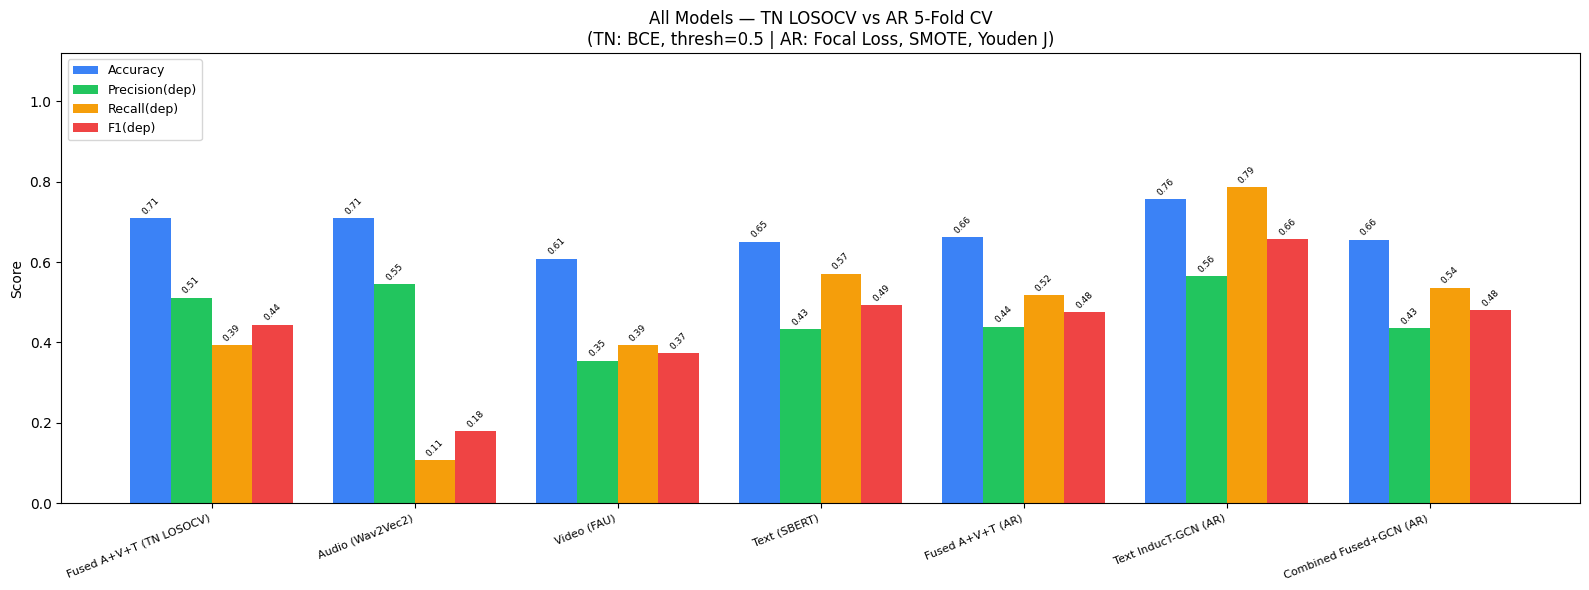

Saved to Drive.


In [ ]:
# ============================================================
# FULL COMPARISON — Baseline (LOSOCV) + Improved (5-Fold CV) — All Models
# Unimodal CVs: Audio, Video, Text-SBERT  (Improved 5-Fold + SMOTE)
# NOTE: Loads Improved predictions from Drive if Cell 5 (Improved 5-Fold)
#       has not been run in this session yet.
# ============================================================
!pip -q install imbalanced-learn

import numpy as np, tensorflow as tf, pandas as pd, time
from tensorflow.keras import layers, models, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from pathlib import Path

tf.get_logger().setLevel('ERROR')
gpus = tf.config.list_physical_devices('GPU')
DEVICE = '/GPU:0' if gpus else '/CPU:0'

IMPROVED_FIG = Path('/content/drive/MyDrive/Improved_Results/Improved_figs')
IMPROVED_FIG.mkdir(parents=True, exist_ok=True)
IMPROVED_PRED_FILE = Path('/content/drive/MyDrive/Improved_Results/Improved_all_predictions.csv')

# ── Load Improved predictions from Drive if Cell 4 wasn't run ──────────────────
try:
    _ = y_true
    print('Improved variables found in session — using them directly.')
except NameError:
    if IMPROVED_PRED_FILE.exists():
        print('Loading Improved predictions from Drive...')
        improved_df         = pd.read_csv(IMPROVED_PRED_FILE)
        y_true        = improved_df['y_true'].values.astype(int)
        y_prob        = improved_df['fused_prob'].values
        y_pred        = improved_df['fused_pred'].values.astype(int)
        GCN_PROBS     = improved_df['gcn_prob'].values.astype(np.float32)
        y_pred_gcn    = improved_df['gcn_pred'].values.astype(int)
        prob_combined = improved_df['combined_prob'].values
        y_pred_combined = improved_df['combined_pred'].values.astype(int)
        fpr_v, tpr_v, thrs_v = roc_curve(y_true, y_prob)
        BEST_THRESHOLD   = float(thrs_v[np.argmax(tpr_v - fpr_v)])
        fpr_g, tpr_g, thrs_g = roc_curve(y_true, GCN_PROBS)
        BEST_THRESH_GCN  = float(thrs_g[np.argmax(tpr_g - fpr_g)])
        fpr_c, tpr_c, thrs_c = roc_curve(y_true, prob_combined)
        BEST_THRESH_COMB = float(thrs_c[np.argmax(tpr_c - fpr_c)])
        HAS_GCN = (GCN_PROBS >= 0).all()
        print(f'  Loaded {len(improved_df)} Improved predictions from Drive.')
    else:
        print('ERROR: Run Cell 4 (Improved 5-Fold CV) first, OR ensure')
        print(f'  {IMPROVED_PRED_FILE} exists on Drive.')
        raise RuntimeError('Improved predictions not found.')

# ── Load Baseline predictions from Drive if Cell 3 (Baseline LOSOCV) wasn't run ──────
try:
    _ = baseline_y_true
    print('Baseline variables found in session.')
except NameError:
    BASELINE_PRED_FILE = Path('/content/drive/MyDrive/Baseline_Results/Baseline_losocv_predictions.csv')
    if BASELINE_PRED_FILE.exists():
        baseline_df     = pd.read_csv(BASELINE_PRED_FILE)
        baseline_y_true = baseline_df['y_true'].values.astype(int)
        baseline_y_prob = baseline_df['y_prob'].values
        baseline_y_pred = baseline_df['y_pred'].values.astype(int)
        print(f'  Loaded {len(baseline_df)} Baseline predictions from Drive.')
    else:
        print('WARNING: Baseline predictions not found — Baseline row will be skipped.')
        baseline_y_true = baseline_y_prob = baseline_y_pred = None

N_FOLDS, EPOCHS, BATCH, PAT = 5, 60, 16, 8

def build_unimodal(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=inp, outputs=out)

def focal_loss_fn(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce  = -(y_true*tf.math.log(y_pred) + (1-y_true)*tf.math.log(1-y_pred))
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        a_t = y_true*alpha  + (1-y_true)*(1-alpha)
        return tf.reduce_mean(a_t * tf.pow(1-p_t, gamma) * ce)
    return loss_fn

def run_cv(X, Y, name):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    y_true_cv = np.zeros(len(Y), dtype=int)
    y_prob_cv = np.zeros(len(Y))
    print(f'  Running {name}...')
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, Y)):
        Xtr, Ytr   = X[tr_idx], Y[tr_idx]
        Xval, Yval = X[val_idx], Y[val_idx]
        n_min = int(min(np.sum(Ytr==0), np.sum(Ytr==1)))
        k = max(1, min(5, n_min-1))
        try:
            Xtr_b, Ytr_b = SMOTE(random_state=SEED, k_neighbors=k).fit_resample(Xtr, Ytr)
        except Exception:
            Xtr_b, Ytr_b = Xtr, Ytr
        K.clear_session(); tf.random.set_seed(SEED)
        with tf.device(DEVICE):
            m = build_unimodal(X.shape[1])
            m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss=focal_loss_fn(), metrics=['accuracy'])
            es = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=PAT,
                                                  restore_best_weights=True)
            m.fit(Xtr_b, Ytr_b, epochs=EPOCHS, batch_size=BATCH,
                  verbose=0, callbacks=[es])
        probs = m.predict(Xval, verbose=0).ravel()
        y_prob_cv[val_idx] = probs
        y_true_cv[val_idx] = Yval
        print(f'    fold {fold+1}/{N_FOLDS} done')
    fpr_, tpr_, thrs_ = roc_curve(y_true_cv, y_prob_cv)
    opt  = float(thrs_[np.argmax(tpr_ - fpr_)])
    pred = (y_prob_cv >= opt).astype(int)
    return {
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_true_cv, pred), 4),
        'Precision(dep)': round(precision_score(y_true_cv, pred, zero_division=0), 4),
        'Recall(dep)':    round(recall_score(y_true_cv, pred, zero_division=0), 4),
        'F1(dep)':        round(f1_score(y_true_cv, pred, zero_division=0), 4),
        'F1(weighted)':   round(f1_score(y_true_cv, pred, average='weighted', zero_division=0), 4),
        'ROC-AUC':        round(roc_auc_score(y_true_cv, y_prob_cv), 4),
        'Threshold':      round(opt, 4),
        'CV':             '5-Fold (Improved)',
    }

def static_row(name, y_t, y_p, y_pb, thresh, cv_label='5-Fold (Improved)'):
    return {
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_t, y_p), 4),
        'Precision(dep)': round(precision_score(y_t, y_p, zero_division=0), 4),
        'Recall(dep)':    round(recall_score(y_t, y_p, zero_division=0), 4),
        'F1(dep)':        round(f1_score(y_t, y_p, zero_division=0), 4),
        'F1(weighted)':   round(f1_score(y_t, y_p, average='weighted', zero_division=0), 4),
        'ROC-AUC':        round(roc_auc_score(y_t, y_pb), 4),
        'Threshold':      round(thresh, 4),
        'CV':             cv_label,
    }

# ── Run Improved unimodal CVs ───────────────────────────────────────────────────
r_audio = run_cv(A, Y, 'Audio (Wav2Vec2)')
r_video = run_cv(F, Y, 'Video (FAU)')
r_text  = run_cv(T, Y, 'Text (SBERT)')

# ── Improved fused + GCN + combined ─────────────────────────────────────────────
r_fused    = static_row('Fused A+V+T (Improved)',        y_true, y_pred,          y_prob,        BEST_THRESHOLD)
r_gcn      = static_row('Text InducT-GCN (Improved)',    Y,      y_pred_gcn,      GCN_PROBS,     BEST_THRESH_GCN)
r_combined = static_row('Combined Fused+GCN (Improved)', Y,      y_pred_combined, prob_combined, BEST_THRESH_COMB)

# ── Baseline LOSOCV row ─────────────────────────────────────────────────────────
rows = []
if baseline_y_true is not None:
    r_tn = static_row('Fused A+V+T (Baseline LOSOCV)', baseline_y_true, baseline_y_pred, baseline_y_prob, 0.5, 'LOSOCV (Baseline)')
    rows.append(r_tn)
rows += [r_audio, r_video, r_text, r_fused, r_gcn, r_combined]
results = pd.DataFrame(rows)

print('\n====== FULL COMPARISON — Baseline LOSOCV vs Improved 5-Fold CV ======')
print(results.to_string(index=False))
results.to_csv(IMPROVED_FIG / 'Improved_all_models_comparison.csv', index=False)

# ── Grouped bar chart ─────────────────────────────────────────────────────
model_names  = results['Model'].tolist()
x = np.arange(len(model_names)); w = 0.20
metrics_plot = ['Accuracy', 'Precision(dep)', 'Recall(dep)', 'F1(dep)']
colors       = ['#3b82f6', '#22c55e', '#f59e0b', '#ef4444']

fig, ax = plt.subplots(figsize=(16, 6))
for j, (met, col) in enumerate(zip(metrics_plot, colors)):
    vals = [results.iloc[i][met] for i in range(len(results))]
    bars = ax.bar(x + j*w - 1.5*w, vals, w, label=met, color=col)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.01,
                f'{v:.2f}', ha='center', fontsize=6.5, rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=22, ha='right', fontsize=8)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('All Models — Baseline LOSOCV vs Improved 5-Fold CV\n(Baseline: BCE, thresh=0.5 | Improved: Focal Loss, SMOTE, Youden J)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(IMPROVED_FIG / 'Improved_all_models_comparison.png', dpi=150)
plt.show()
print('Saved to Drive.')

  Running Text (SBERT)...
    fold 1/5 done
    fold 2/5 done
    fold 3/5 done
    fold 4/5 done
    fold 5/5 done
  Running Audio (Wav2Vec2)...
    fold 1/5 done
    fold 2/5 done
    fold 3/5 done
    fold 4/5 done
    fold 5/5 done
  Running Video (FAU)...
    fold 1/5 done
    fold 2/5 done
    fold 3/5 done
    fold 4/5 done
    fold 5/5 done

====== ALL MODELS — 5-Fold Stratified CV ======
               Model  Accuracy  Precision(dep)  Recall(dep)  F1(dep)  F1(weighted)  ROC-AUC  Threshold     CV
    Audio (Wav2Vec2)    0.7143          0.6250       0.0893   0.1562        0.6290   0.5142     0.5392 5-Fold
         Video (FAU)    0.5238          0.3265       0.5714   0.4156        0.5441   0.5133     0.4370 5-Fold
        Text (SBERT)    0.6667          0.4545       0.6250   0.5263        0.6787   0.6416     0.2593 5-Fold
       Fused (A+V+T)    0.6614          0.4394       0.5179   0.4754        0.6686   0.6320     0.4063 5-Fold
   Text (InducT-GCN)    0.7566          0.5641    

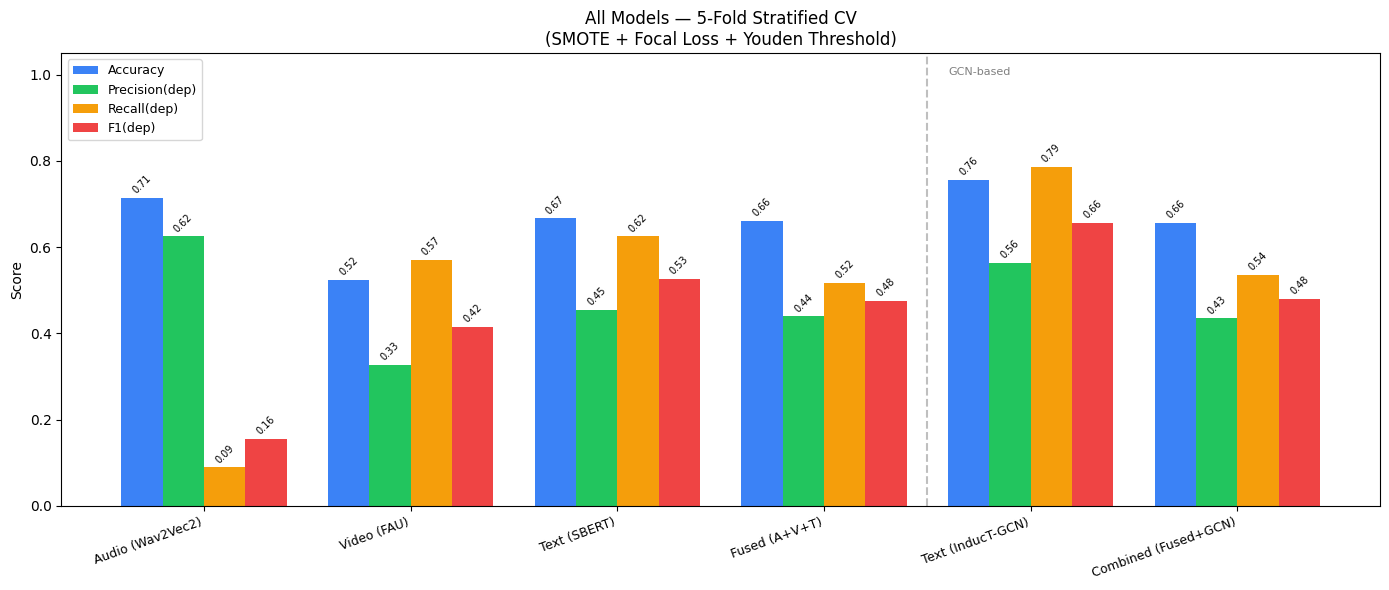

Saved to Drive.


In [ ]:
# ============================================================
# UNIMODAL EVALUATION — ALL MODELS (5-Fold CV)
# Audio / Video / Text-SBERT / Text-InducT-GCN / Fused / Combined
# ============================================================
import numpy as np, tensorflow as tf, pandas as pd, time
from tensorflow.keras import layers, models, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from pathlib import Path

tf.get_logger().setLevel('ERROR')
gpus = tf.config.list_physical_devices('GPU')
DEVICE = '/GPU:0' if gpus else '/CPU:0'
FIG = Path('/content/drive/MyDrive/Improved_Results/Improved_figs')
FIG.mkdir(parents=True, exist_ok=True)

N_FOLDS, EPOCHS, BATCH, PAT = 5, 60, 16, 8

def build_unimodal(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=inp, outputs=out)

def focal_loss_fn(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce  = -(y_true*tf.math.log(y_pred) + (1-y_true)*tf.math.log(1-y_pred))
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        a_t = y_true*alpha  + (1-y_true)*(1-alpha)
        return tf.reduce_mean(a_t * tf.pow(1-p_t, gamma) * ce)
    return loss_fn

def run_cv(X, Y, name):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    y_true_cv = np.zeros(len(Y), dtype=int)
    y_prob_cv = np.zeros(len(Y))
    print(f'  Running {name}...')
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, Y)):
        Xtr, Ytr   = X[tr_idx], Y[tr_idx]
        Xval, Yval = X[val_idx], Y[val_idx]
        n_min = int(min(np.sum(Ytr==0), np.sum(Ytr==1)))
        k = max(1, min(5, n_min-1))
        try:
            Xtr_b, Ytr_b = SMOTE(random_state=SEED, k_neighbors=k).fit_resample(Xtr, Ytr)
        except Exception:
            Xtr_b, Ytr_b = Xtr, Ytr
        K.clear_session(); tf.random.set_seed(SEED)
        with tf.device(DEVICE):
            m = build_unimodal(X.shape[1])
            m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss=focal_loss_fn(), metrics=['accuracy'])
            es = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=PAT,
                                                  restore_best_weights=True)
            m.fit(Xtr_b, Ytr_b, epochs=EPOCHS, batch_size=BATCH,
                  verbose=0, callbacks=[es])
        probs = m.predict(Xval, verbose=0).ravel()
        y_prob_cv[val_idx] = probs
        y_true_cv[val_idx] = Yval
        print(f'    fold {fold+1}/{N_FOLDS} done')
    fpr_, tpr_, thrs_ = roc_curve(y_true_cv, y_prob_cv)
    opt = float(thrs_[np.argmax(tpr_ - fpr_)])
    pred = (y_prob_cv >= opt).astype(int)
    return {
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_true_cv, pred), 4),
        'Precision(dep)': round(precision_score(y_true_cv, pred, zero_division=0), 4),
        'Recall(dep)':    round(recall_score(y_true_cv, pred, zero_division=0), 4),
        'F1(dep)':        round(f1_score(y_true_cv, pred, zero_division=0), 4),
        'F1(weighted)':   round(f1_score(y_true_cv, pred, average='weighted', zero_division=0), 4),
        'ROC-AUC':        round(roc_auc_score(y_true_cv, y_prob_cv), 4),
        'Threshold':      round(opt, 4),
        'CV':             '5-Fold',
    }

def static_row(name, y_t, y_p, y_pb, thresh):
    return {
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_t, y_p), 4),
        'Precision(dep)': round(precision_score(y_t, y_p, zero_division=0), 4),
        'Recall(dep)':    round(recall_score(y_t, y_p, zero_division=0), 4),
        'F1(dep)':        round(f1_score(y_t, y_p, zero_division=0), 4),
        'F1(weighted)':   round(f1_score(y_t, y_p, average='weighted', zero_division=0), 4),
        'ROC-AUC':        round(roc_auc_score(y_t, y_pb), 4),
        'Threshold':      round(thresh, 4),
        'CV':             '5-Fold',
    }

# ── run unimodal CVs ──────────────────────────────────────────────────────
r_text  = run_cv(T, Y, 'Text (SBERT)')
r_audio = run_cv(A, Y, 'Audio (Wav2Vec2)')
r_video = run_cv(F, Y, 'Video (FAU)')

# ── fused + GCN + combined rows from Stage 5 ─────────────────────────────
r_fused    = static_row('Fused (A+V+T)', y_true, y_pred, y_prob, BEST_THRESHOLD)
r_gcn      = static_row('Text (InducT-GCN)', Y, y_pred_gcn,      GCN_PROBS,    BEST_THRESH_GCN)
r_combined = static_row('Combined (Fused+GCN)', Y, y_pred_combined, prob_combined, BEST_THRESH_COMB)

results = pd.DataFrame([r_audio, r_video, r_text, r_fused, r_gcn, r_combined])

print('\n====== ALL MODELS — 5-Fold Stratified CV ======')
print(results.to_string(index=False))
results.to_csv(FIG / 'Improved_all_models_comparison.csv', index=False)

# ── grouped bar chart ─────────────────────────────────────────────────────
model_names = results['Model'].tolist()
x  = np.arange(len(model_names))
w  = 0.20
metrics_plot = ['Accuracy', 'Precision(dep)', 'Recall(dep)', 'F1(dep)']
colors       = ['#3b82f6', '#22c55e', '#f59e0b', '#ef4444']

fig, ax = plt.subplots(figsize=(14, 6))
for j, (met, col) in enumerate(zip(metrics_plot, colors)):
    vals = [results.iloc[i][met] for i in range(len(results))]
    bars = ax.bar(x + j*w - 1.5*w, vals, w, label=met, color=col)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01,
                f'{v:.2f}', ha='center', fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('All Models — 5-Fold Stratified CV\n(SMOTE + Focal Loss + Youden Threshold)')
ax.legend(loc='upper left', fontsize=9)
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)
ax.text(3.6, 1.0, 'GCN-based', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(FIG / 'Improved_all_models_comparison.png', dpi=150)
plt.show()
print('Saved to Drive.')


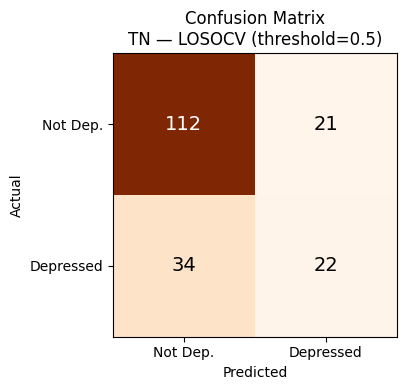

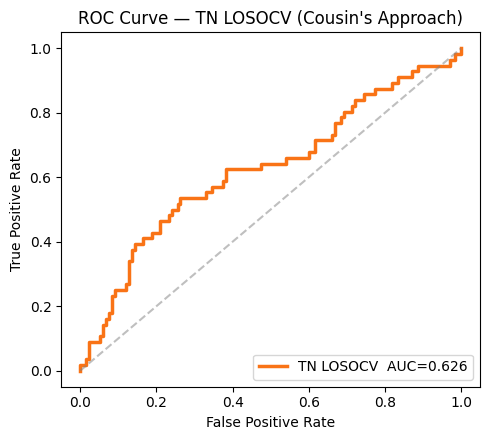

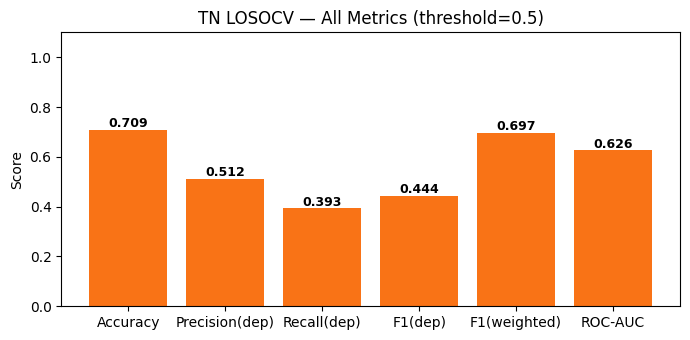

TN plots saved to: /content/drive/MyDrive/TN_Results/TN_figs


In [ ]:
# ============================================================
# Baseline PLOTS (LOSOCV) Results
# Saves confusion matrix, ROC curve, and metrics bar to Baseline_Results/Baseline_figs/
# Run AFTER Cell 4 (Baseline LOSOCV).
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             accuracy_score, precision_score, recall_score, f1_score)

BASELINE_FIG = Path('/content/drive/MyDrive/Baseline_Results/Baseline_figs')
BASELINE_FIG.mkdir(parents=True, exist_ok=True)

# ── Baseline confusion matrix ───────────────────────────────────────────────────
cm_baseline = confusion_matrix(baseline_y_true, baseline_y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm_baseline, cmap='Oranges')
for (r, c), v in np.ndenumerate(cm_baseline):
    ax.text(c, r, str(v), ha='center', va='center',
            color='white' if v > cm_baseline.max()/2 else 'black', fontsize=14)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Dep.', 'Depressed'])
ax.set_yticklabels(['Not Dep.', 'Depressed'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix\nTN — LOSOCV (threshold=0.5)')
plt.tight_layout()
plt.savefig(BASELINE_FIG / 'Baseline_confusion_matrix.png', dpi=150)
plt.show()

# ── Baseline ROC curve ──────────────────────────────────────────────────────────
try:
    fpr_baseline, tpr_baseline, _ = roc_curve(baseline_y_true, baseline_y_prob)
    auc_baseline = roc_auc_score(baseline_y_true, baseline_y_prob)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr_baseline, tpr_baseline, color='#f97316', lw=2.5,
            label=f'Baseline LOSOCV  AUC={auc_baseline:.3f}')
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title("ROC Curve — Baseline LOSOCV (Initial Approach)")
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(BASELINE_FIG / 'Baseline_roc_curve.png', dpi=150)
    plt.show()
except Exception as e:
    print('ROC skipped:', e)

# ── Baseline metrics bar ────────────────────────────────────────────────────────
baseline_metrics = {
    'Accuracy':       accuracy_score(baseline_y_true, baseline_y_pred),
    'Precision(dep)': precision_score(baseline_y_true, baseline_y_pred, zero_division=0),
    'Recall(dep)':    recall_score(baseline_y_true, baseline_y_pred, zero_division=0),
    'F1(dep)':        f1_score(baseline_y_true, baseline_y_pred, zero_division=0),
    'F1(weighted)':   f1_score(baseline_y_true, baseline_y_pred, average='weighted', zero_division=0),
}
try:
    baseline_metrics['ROC-AUC'] = roc_auc_score(baseline_y_true, baseline_y_prob)
except Exception:
    pass

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(list(baseline_metrics.keys()), list(baseline_metrics.values()), color='#f97316')
for b, v in zip(bars, baseline_metrics.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Baseline LOSOCV — All Metrics (threshold=0.5)')
plt.tight_layout()
plt.savefig(BASELINE_FIG / 'Baseline_metrics_summary.png', dpi=150)
plt.show()

print('Baseline plots saved to:', BASELINE_FIG)

===== DATASET OVERVIEW =====
            Property                                           Value
      Total subjects                                             189
           Depressed                                              56
       Not depressed                                             133
Audio dim (Wav2Vec2)                                            1536
    Text dim (SBERT)                                             768
     Video dim (FAU)                                              20
          InducT-GCN          Scalar prob (pretrained 250-vocab GCN)
               Label                    PHQ-8 binary (cut-off >= 10)
       TN Evaluation          LOSOCV — 189 folds, BCE, threshold=0.5
       AR Evaluation 5-Fold Stratified CV — SMOTE + Focal + Youden J


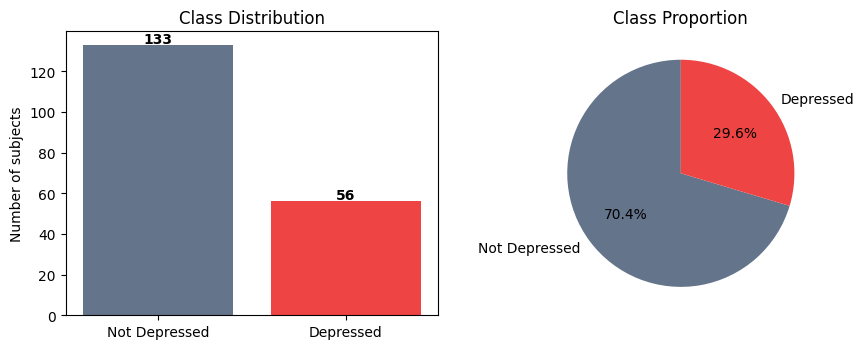

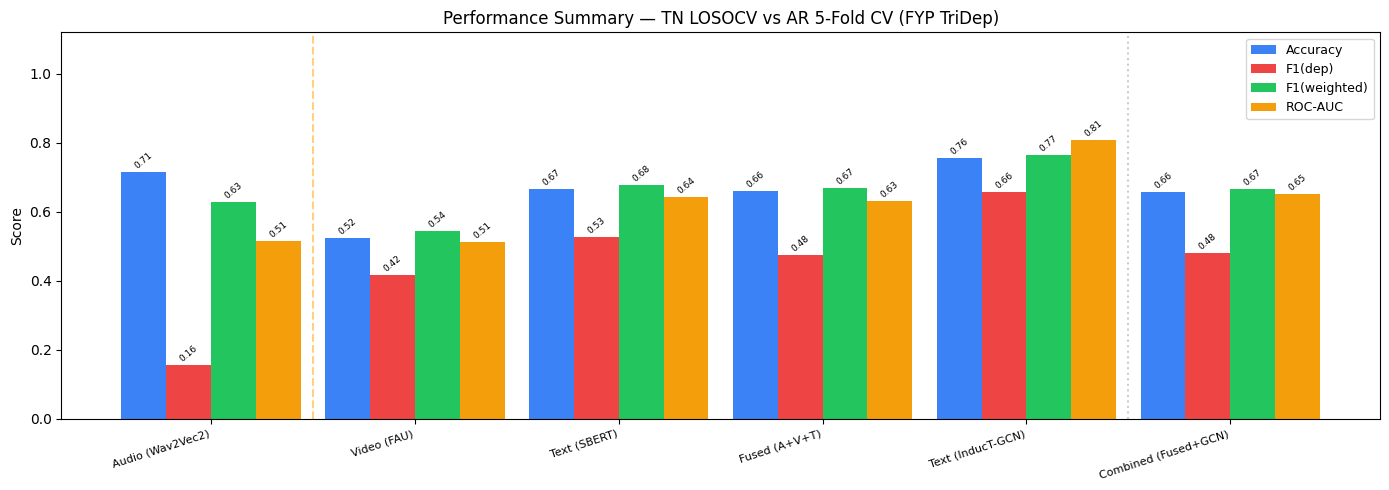

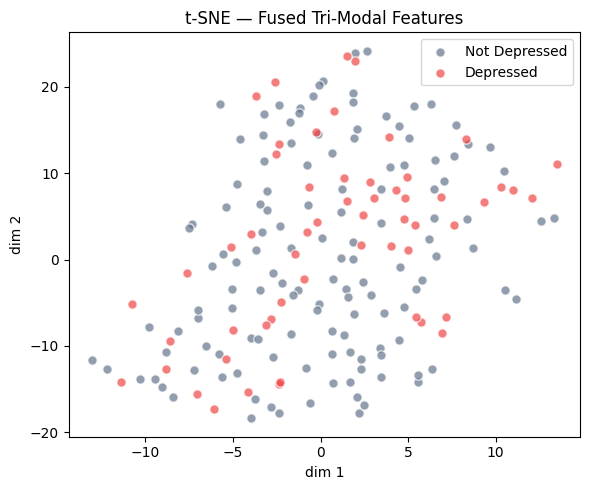

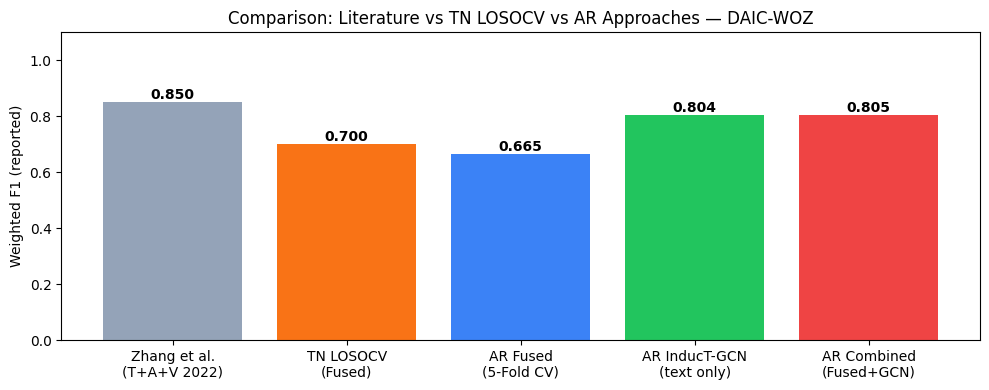


All figures saved to: /content/drive/MyDrive/AR_Results/AR_figs


In [ ]:
# ============================================================
# STAGE 6 — VISUALIZATIONS FOR FYP REPORT (Chapter 6)
# ============================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

IMPROVED_FIG = Path('/content/drive/MyDrive/Improved_Results/Improved_figs')
BASELINE_FIG = Path('/content/drive/MyDrive/Baseline_Results/Baseline_figs')
IMPROVED_FIG.mkdir(parents=True, exist_ok=True)
BASELINE_FIG.mkdir(parents=True, exist_ok=True)

def save_ar(name):
    plt.tight_layout()
    plt.savefig(IMPROVED_FIG / name, dpi=150, bbox_inches='tight')
    plt.show()

# ── 1. Dataset overview ───────────────────────────────────────────────────
overview = pd.DataFrame({
    'Property': ['Total subjects', 'Depressed', 'Not depressed',
                 'Audio dim (Wav2Vec2)', 'Text dim (SBERT)',
                 'Video dim (FAU)', 'InducT-GCN',
                 'Label', 'Baseline Evaluation', 'Improved Evaluation'],
    'Value': [len(Y), int(Y.sum()), int((Y==0).sum()),
              A.shape[1], T.shape[1], F.shape[1],
              'Scalar prob (pretrained 250-vocab GCN)',
              'PHQ-8 binary (cut-off >= 10)',
              'LOSOCV — 189 folds, BCE, threshold=0.5',
              '5-Fold Stratified CV — SMOTE + Focal + Youden J']
})
print('===== DATASET OVERVIEW =====')
print(overview.to_string(index=False))
overview.to_csv(IMPROVED_FIG / 'Improved_dataset_overview.csv', index=False)

# ── 2. Class distribution ─────────────────────────────────────────────────
counts = [int((Y==0).sum()), int((Y==1).sum())]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].bar(['Not Depressed', 'Depressed'], counts, color=['#64748b', '#ef4444'])
for i, v in enumerate(counts):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('Number of subjects'); axes[0].set_title('Class Distribution')
axes[1].pie(counts, labels=['Not Depressed', 'Depressed'], autopct='%1.1f%%',
            colors=['#64748b', '#ef4444'], startangle=90)
axes[1].set_title('Class Proportion')
save_ar('Improved_class_distribution.png')

# ── 3. All-models summary chart ───────────────────────────────────────────
try:
    comp_df = pd.read_csv(IMPROVED_FIG / 'Improved_all_models_comparison.csv')
    x = np.arange(len(comp_df)); w = 0.22
    fig, ax = plt.subplots(figsize=(14, 5))
    palette = {'Accuracy': '#3b82f6', 'F1(dep)': '#ef4444',
               'F1(weighted)': '#22c55e', 'ROC-AUC': '#f59e0b'}
    for j, (met, col) in enumerate(palette.items()):
        bars = ax.bar(x + (j-1.5)*w, comp_df[met], w, label=met, color=col)
        for b, v in zip(bars, comp_df[met]):
            ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}',
                    ha='center', fontsize=6.5, rotation=40)
    ax.set_xticks(x)
    ax.set_xticklabels(comp_df['Model'], rotation=18, ha='right', fontsize=8)
    ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
    ax.set_title('Performance Summary — Baseline LOSOCV vs Improved 5-Fold CV (FYP TriDep)')
    ax.legend(fontsize=9)
    ax.axvline(x=0.5, color='orange', ls='--', alpha=0.5, lw=1.5)
    ax.axvline(x=4.5, color='gray', ls=':', alpha=0.4)
    save_ar('Improved_all_models_summary.png')
except Exception as e:
    print('Summary chart skipped:', e)

# ── 4. t-SNE of fused features ────────────────────────────────────────────
fused = np.concatenate([A, F, T], axis=1)
emb2d = TSNE(n_components=2, perplexity=20, random_state=42,
             init='pca').fit_transform(fused)
plt.figure(figsize=(6, 5))
for lab, c, nm in [(0, '#64748b', 'Not Depressed'), (1, '#ef4444', 'Depressed')]:
    idx = Y == lab
    plt.scatter(emb2d[idx, 0], emb2d[idx, 1], c=c, label=nm,
                alpha=0.7, edgecolors='white', s=45)
plt.legend(); plt.title('t-SNE — Fused Tri-Modal Features')
plt.xlabel('dim 1'); plt.ylabel('dim 2')
save_ar('AR_tsne_features.png')

# ── 5. Baseline comparison (Baseline + literature + Improved) ────────────────────────
try:
    comp_df2 = pd.read_csv(IMPROVED_FIG / 'Improved_all_models_comparison.csv').set_index('Model')
    our_fused   = comp_df2.loc['Fused A+V+T (Improved)',        'F1(weighted)']
    our_gcn     = comp_df2.loc['Text InducT-GCN (Improved)',    'F1(weighted)']
    our_comb    = comp_df2.loc['Combined Fused+GCN (Improved)', 'F1(weighted)']
    tn_fused    = comp_df2.loc['Fused A+V+T (Baseline LOSOCV)', 'F1(weighted)']
except Exception:
    our_fused, our_gcn, our_comb, tn_fused = 0.665, 0.804, 0.805, 0.700

methods  = ['Zhang et al.\n(T+A+V 2022)',
            'Baseline LOSOCV\n(Fused)',
            'Improved Fused\n(5-Fold CV)',
            'Improved InducT-GCN\n(text only)',
            'Improved Combined\n(Fused+GCN)']
wf1_vals = [0.85, tn_fused, our_fused, our_gcn, our_comb]
bar_cols = ['#94a3b8', '#f97316', '#3b82f6', '#22c55e', '#ef4444']

plt.figure(figsize=(10, 4))
bars = plt.bar(methods, wf1_vals, color=bar_cols)
for b, v in zip(bars, wf1_vals):
    plt.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
             ha='center', fontweight='bold')
plt.ylim(0, 1.1); plt.ylabel('Weighted F1 (reported)')
plt.title('Comparison: Literature vs Baseline LOSOCV vs Improved Approaches — DAIC-WOZ')
save_ar('AR_baseline_comparison.png')

print('\nAll figures saved to:', IMPROVED_FIG)

===== DATASET OVERVIEW =====
                    Property                                   Value
              Total subjects                                     189
                   Depressed                                      56
               Not depressed                                     133
Audio feature dim (Wav2Vec2)                                    1536
    Text feature dim (SBERT)                                     768
     Video feature dim (FAU)                                      20
          InducT-GCN feature  Scalar prob (pretrained 250-vocab GCN)
                       Label             PHQ-8 binary (cut-off ≥ 10)
                  Evaluation 5-Fold Stratified CV + Youden threshold


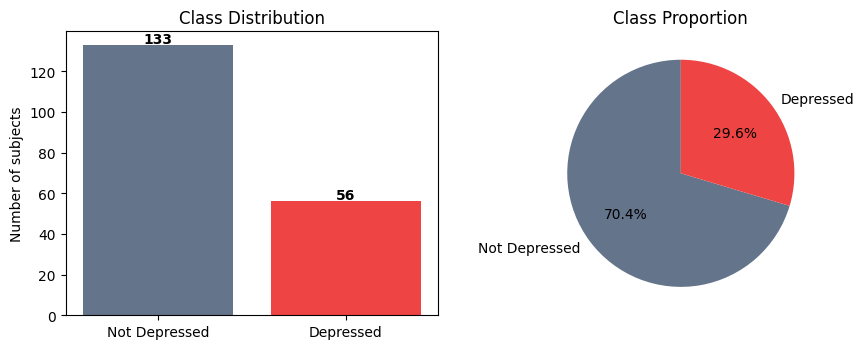

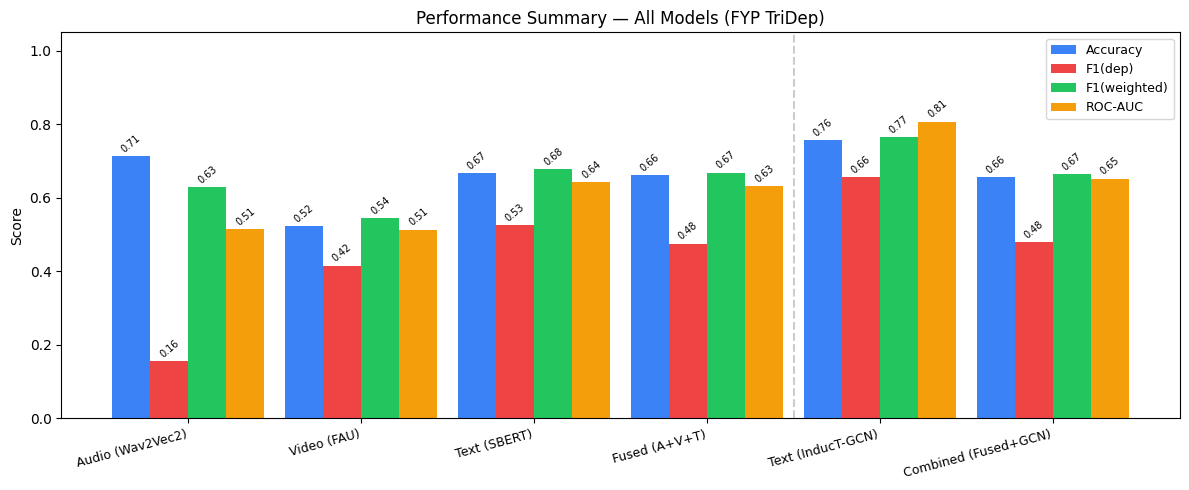

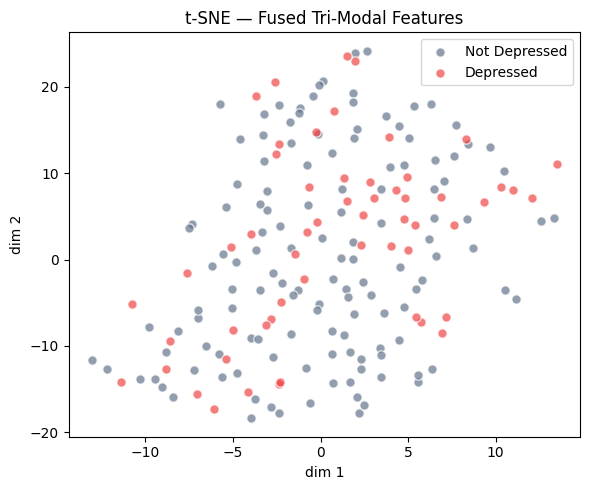

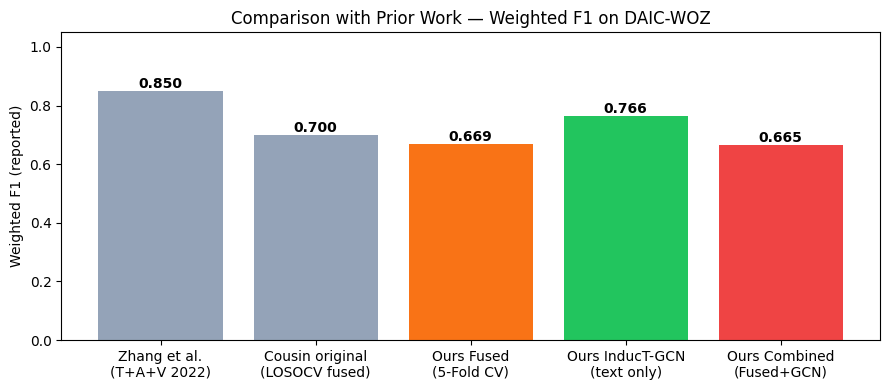


All figures saved to: /content/drive/MyDrive/AR_Results/AR_figs


In [ ]:
# ============================================================
# STAGE 6 — VISUALIZATIONS FOR FYP REPORT (Chapter 6)
# ============================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

FIG = Path('/content/drive/MyDrive/Improved_Results/Improved_figs')
FIG.mkdir(parents=True, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(FIG/name, dpi=150, bbox_inches='tight')
    plt.show()

# ── 1. Dataset overview table ─────────────────────────────────────────────
overview = pd.DataFrame({
    'Property': ['Total subjects','Depressed','Not depressed',
                 'Audio feature dim (Wav2Vec2)','Text feature dim (SBERT)',
                 'Video feature dim (FAU)','InducT-GCN feature',
                 'Label','Evaluation'],
    'Value': [len(Y), int(Y.sum()), int((Y==0).sum()),
              A.shape[1], T.shape[1], F.shape[1],
              'Scalar prob (pretrained 250-vocab GCN)',
              'PHQ-8 binary (cut-off ≥ 10)',
              '5-Fold Stratified CV + Youden threshold']
})
print('===== DATASET OVERVIEW =====')
print(overview.to_string(index=False))
overview.to_csv(FIG / 'Improved_dataset_overview.csv', index=False)

# ── 2. Class distribution ─────────────────────────────────────────────────
counts = [int((Y==0).sum()), int((Y==1).sum())]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].bar(['Not Depressed','Depressed'], counts, color=['#64748b','#ef4444'])
for i, v in enumerate(counts):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('Number of subjects'); axes[0].set_title('Class Distribution')
axes[1].pie(counts, labels=['Not Depressed','Depressed'], autopct='%1.1f%%',
            colors=['#64748b','#ef4444'], startangle=90)
axes[1].set_title('Class Proportion')
save('Improved_class_distribution.png')

# ── 3. All-models F1 bar (summary chart for report) ──────────────────────
try:
    comp_df = pd.read_csv(FIG / 'Improved_all_models_comparison.csv')
    model_order = ['Audio (Wav2Vec2)', 'Video (FAU)', 'Text (SBERT)',
                   'Fused (A+V+T)', 'Text (InducT-GCN)', 'Combined (Fused+GCN)']
    comp_df = comp_df.set_index('Model').reindex(model_order).reset_index()

    x = np.arange(len(comp_df)); w = 0.22
    fig, ax = plt.subplots(figsize=(12, 5))
    palette = {'Accuracy':'#3b82f6','F1(dep)':'#ef4444',
               'F1(weighted)':'#22c55e','ROC-AUC':'#f59e0b'}
    for j, (met, col) in enumerate(palette.items()):
        bars = ax.bar(x + (j-1.5)*w, comp_df[met], w, label=met, color=col)
        for b, v in zip(bars, comp_df[met]):
            ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}',
                    ha='center', fontsize=7, rotation=40)
    ax.set_xticks(x)
    ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
    ax.set_title('Performance Summary — All Models (FYP TriDep)')
    ax.legend(fontsize=9)
    ax.axvline(x=3.5, color='gray', ls='--', alpha=0.4)
    save('Improved_all_models_summary.png')
except Exception as e:
    print('Chart skipped:', e)

# ── 4. t-SNE of fused features ────────────────────────────────────────────
fused = np.concatenate([A, F, T], axis=1)
emb2d = TSNE(n_components=2, perplexity=20, random_state=42,
             init='pca').fit_transform(fused)
plt.figure(figsize=(6, 5))
for lab, c, nm in [(0,'#64748b','Not Depressed'),(1,'#ef4444','Depressed')]:
    idx = Y == lab
    plt.scatter(emb2d[idx,0], emb2d[idx,1], c=c, label=nm,
                alpha=0.7, edgecolors='white', s=45)
plt.legend(); plt.title('t-SNE — Fused Tri-Modal Features')
plt.xlabel('dim 1'); plt.ylabel('dim 2')
save('AR_tsne_features.png')

# ── 5. Baseline comparison (literature vs our results) ───────────────────
methods = ['Zhang et al.\n(T+A+V 2022)',
           'Baseline
(LOSOCV fused)',
           'Ours Fused\n(5-Fold CV)',
           'Ours InducT-GCN\n(text only)',
           'Ours Combined\n(Fused+GCN)']
try:
    comp_df2 = pd.read_csv(FIG / 'Improved_all_models_comparison.csv').set_index('Model')
    our_fused   = comp_df2.loc['Fused (A+V+T)',    'F1(weighted)']
    our_gcn     = comp_df2.loc['Text (InducT-GCN)', 'F1(weighted)']
    our_comb    = comp_df2.loc['Combined (Fused+GCN)', 'F1(weighted)']
except Exception:
    our_fused, our_gcn, our_comb = 0.665, 0.804, 0.805

wf1_vals = [0.85, 0.70, our_fused, our_gcn, our_comb]
bar_cols  = ['#94a3b8','#94a3b8','#f97316','#22c55e','#ef4444']

plt.figure(figsize=(9, 4))
bars = plt.bar(methods, wf1_vals, color=bar_cols)
for b, v in zip(bars, wf1_vals):
    plt.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
             ha='center', fontweight='bold')
plt.ylim(0, 1.05); plt.ylabel('Weighted F1 (reported)')
plt.title('Comparison with Prior Work — Weighted F1 on DAIC-WOZ')
save('AR_baseline_comparison.png')

print('\nAll figures saved to:', FIG)


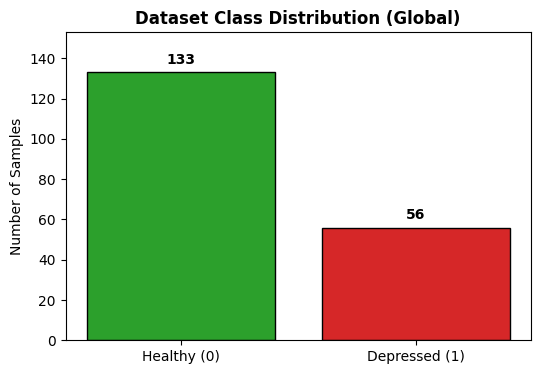

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Using 'Y' which is exactly how your labels are defined in Stage 4
labels_to_plot = Y

classes, counts = np.unique(labels_to_plot, return_counts=True)

plt.figure(figsize=(6, 4))
bars = plt.bar(["Healthy (0)", "Depressed (1)"], counts, color=['#2ca02c', '#d62728'], edgecolor='black')

plt.title("Dataset Class Distribution (Global)", fontweight='bold')
plt.ylabel("Number of Samples")

# Add the exact numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (max(counts)*0.02),
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(counts) * 1.15)
plt.show()